In [109]:
import seaborn as sns
import pandas as pd
df = sns.load_dataset('titanic')

### Explanation
This cell imports the required libraries and loads the Titanic dataset using Seaborn.

- `seaborn` is used for visualization and accessing built-in datasets.
- `pandas` is used for handling tabular data.
- The Titanic dataset is stored inside the variable `df` as a DataFrame.


In [110]:
df = df.drop(columns=['survived']).sample(800)

### Explanation
This cell prepares the dataset for the Central Limit Theorem (CLT) experiment.

- The `survived` column is removed because it is not needed for this analysis.
- `.sample(800)` randomly selects 800 rows from the dataset.
- Random sampling helps create a representative subset of the population.


<Axes: ylabel='Density'>

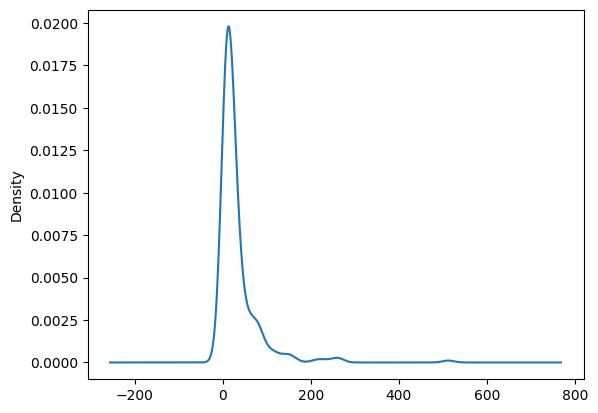

In [111]:
df['fare'].plot(kind='kde')

### Explanation
This cell visualizes the distribution of the `fare` column using a KDE (Kernel Density Estimation) plot.

- KDE shows the shape of the data distribution smoothly.
- This helps us observe whether the original population distribution is normal or skewed.
- In this case, Titanic fares are heavily right-skewed.


In [112]:
samples = []
for i in range(1000):
    samples.append(df['fare'].dropna().sample(50).values.tolist())

### Explanation
This cell creates repeated random samples from the population.

- An empty list called `samples` is created.
- A loop runs 1000 times.
- During each iteration:
  - 50 random fare values are selected.
  - Missing values are removed using `.dropna()`.
  - The sampled values are converted into a list and stored.

At the end, we have:
- 1000 samples
- Each sample contains 50 fare values


In [113]:
import numpy as np
samples = np.array(samples)

### Explanation
This cell converts the list of samples into a NumPy array.

- NumPy arrays allow faster numerical computations.
- The resulting shape becomes:
  - Rows → different samples
  - Columns → values inside each sample


In [114]:
sampling_means = samples.mean(axis=1)

### Explanation
This cell calculates the mean of each sample.

- `axis=1` means:
  - Calculate row-wise means.
- Since each row represents one sample, this gives:
  - One mean per sample.

The result is a sampling distribution of sample means.


<Axes: ylabel='Density'>

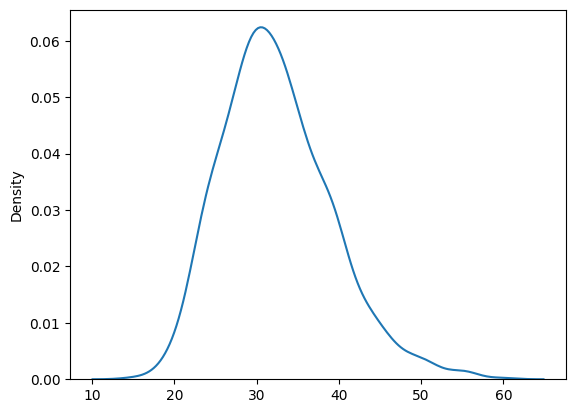

In [121]:
sns.kdeplot(sampling_means)

### Explanation
This cell plots the distribution of the sample means.

- Even if the original population is skewed, the distribution of sample means becomes more normal.
- This demonstrates the Central Limit Theorem (CLT).
- Because the sample size is reasonably large (`n = 50`), the sampling distribution approaches a bell-shaped curve.


In [116]:
sampling_means.mean()

np.float64(32.433787748)

### Explanation
This cell calculates the average of all sample means.

- According to the Central Limit Theorem:
  - The mean of the sampling distribution should be close to the population mean.
- This value estimates the true average fare of the population.


In [117]:
standard_error = df['fare'].dropna().std() / np.sqrt(50)
standard_error

np.float64(7.128181896499736)

### Explanation
This cell calculates the Standard Error.

genui{"math_block_widget_always_prefetch_v2":{"content":"SE = \frac{\sigma}{\sqrt{n}}"}}

Where:
- `σ` = population standard deviation
- `n` = sample size

The standard error measures how much the sample means vary from the population mean.
Smaller standard error means the sample means are more tightly clustered.


In [118]:
lower_limit = sampling_means.mean() - 2*sampling_means.std()
upper_limit = sampling_means.mean() + 2*sampling_means.std()

### Explanation
This cell calculates the lower and upper limits of an approximate confidence interval.

The formula used is:

- Lower Limit = Mean − 2 × Standard Deviation
- Upper Limit = Mean + 2 × Standard Deviation

This creates an approximate 95% range for the sampling distribution.


In [119]:
print('The range is',lower_limit,'-',upper_limit)

The range is 19.106572216717943 - 45.76100327928206


### Explanation
This cell prints the calculated interval range.

- Most sample means are expected to fall within this range.
- This demonstrates how sampling distributions help estimate uncertainty in statistics.


In [120]:
df['fare'].dropna().mean()

np.float64(32.7191295)

### Explanation
This cell calculates the actual population mean of the `fare` column.

- This value is compared with the mean of the sampling distribution.
- If CLT works correctly, both values should be very close.


# Conclusion

This case study demonstrates the **Central Limit Theorem (CLT)** using Titanic fare data.

Key findings:
- The original `fare` distribution is highly skewed.
- Random samples of size 50 were repeatedly taken from the population.
- The mean of each sample was calculated.
- The distribution of these sample means became approximately normal.
- The average of the sample means was very close to the true population mean.
- The standard error measured the variability of sample means.

Overall, this experiment proves that:
> Even when the original population is not normally distributed, the distribution of sample means becomes approximately normal when the sample size is sufficiently large.

This is one of the most important concepts in statistics and forms the foundation of confidence intervals, hypothesis testing, and many machine learning techniques.
